In [43]:
import torch

import numpy as np
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt

from PIL import Image
from tqdm import tqdm
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
from matplotlib.colors import LinearSegmentedColormap

from oracle.presets import get_test_loaders, get_model
from oracle.visualization import plot_plain_cf, plot_confusion_matrix

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using {device} device")
torch.set_default_device(device)

Using cpu device


In [44]:
test_df = pl.read_parquet("../data/ELAsTiCC/test.parquet")
def get_z_from_SNID(SNID):

    result = test_df.filter(pl.col("SNID") == SNID)
    return result.select("SIM_REDSHIFT_CMB").item()

In [45]:
z_df = test_df[['SNID','SIM_REDSHIFT_CMB','ELASTICC_class']]

In [46]:
model_choice =  "ELAsTiCC"
model_dir = "../models/ELAsTiCC/tenebrous-husk-200"
days_for_eval = 2**np.arange(0,11)

model = get_model(model_choice)
model = model.to(device)
model.setup_testing(model_dir, device)    # ensures architecture (num outputs etc.) matches checkpoint
model.load_state_dict(torch.load(f'{model_dir}/best_model_f1.pth', map_location=device), strict=False)
model.eval()

test_loader = get_test_loaders(
    model_choice,
    1024,
    int(1e11),
    days_for_eval,
)

Loading dataset from /Users/vedshah/Documents/Research/NU-Miller/Projects/Hierarchical-VT/data/ELAsTiCC/test.parquet

Mapping ELAsTiCC classes to astrophysical classes...
Limiting the number of samples to a maximum of 100000000000 per class.
AGN: 32681
CART: 3517
Cepheid: 5901
Delta Scuti: 8849
Dwarf Novae: 3439
EB: 28480
ILOT: 3197
KN: 1896
M-dwarf Flare: 796
PISN: 27250
RR Lyrae: 6014
SNI91bg: 12272
SNII: 129230
SNIa: 51745
SNIax: 12012
SNIb/c: 72105
TDE: 28285
high-z-SLSN: 22119
low-z-SLSN: 6203
uLens: 7537
Starting Dataset Transformations:
Replacing band labels with mean wavelengths...
Dropping saturations from MJD series...
Dropping saturations from FLUXCAL series...
Dropping saturations from FLUXCALERR series...
Dropping saturations from BAND series...
Removing saturations from PHOTFLAG series...
Replacing PHOTFLAG bitmask with binary values...
Subtracting time of first observation...
Replacing missing values in MWEBV series...
Replacing missing values in MWEBV_ERR series...
Repl

In [47]:
def plot_confusion_matrix(y_true, y_pred, labels, normalize='true', title=None, img_file=None):
    """
    Plot a confusion matrix using the given true and predicted labels and display it with matplotlib.

    Parameters:
        y_true (array-like): Array of true labels.
        y_pred (array-like): Array of predicted labels corresponding to y_true.
        labels (list): List of label names to be used in the confusion matrix.
        normalize (str, optional): Normalization mode for the confusion matrix. Default is 'true'.
                                   Accepted values are typically 'true', 'pred', or 'all'.
        title (str, optional): Title of the plot; if provided, it will be set on the plot.
        img_file (str, optional): File path to save the generated plot image. If None, the plot is not saved.

    Returns:
        None

    Note:
        - The function filters out any entries where the true label is None.
        - It adjusts the figure size and text properties based on the number of classes.
        - The function closes all previous matplotlib figures at the start and closes the plot at the end.
    """

    plt.close('all')
    plt.style.use(['default'])

    color = 'salmon' if normalize == 'pred' else 'teal'
    c_list = ["#FFFFFF", color]  # White to the model's color
    my_cmap = LinearSegmentedColormap.from_list("custom_blue", c_list, N=256)


    # Only keep source where a true label exists
    idx = np.where(y_true!=None)[0]
    y_true = y_true[idx]
    y_pred = y_pred[idx]
    
    n_class = len(labels)
    font = {'size'   : 25}
    plt.rc('font', **font)
    
    cm = np.round(confusion_matrix(y_true, y_pred, labels=labels, normalize=normalize),2)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
    disp.plot(cmap=my_cmap)
    disp.im_.colorbar.remove()
    
    fig = disp.figure_
    if n_class < 3:
        plt.yticks(rotation=90, verticalalignment='center')
    if n_class > 7:
        plt.xticks(rotation=90)
        plt.yticks(rotation=45)
    
    fig.set_figwidth(18)
    fig.set_figheight(18)
    
    for label in disp.text_.ravel():
        if n_class > 7:
            label.set_fontsize(12)
        elif n_class <= 7 and n_class > 3:
            disp.ax_.tick_params(axis='both', labelsize=40)
            label.set_fontsize('xx-large')
        else:
            disp.ax_.tick_params(axis='both', labelsize=55)

            # change the font size of the metrics in the confusion matrix
            disp.ax_.tick_params(axis='both', labelsize='xx-large')

            label.set_fontsize(65)
    
    if title:
        disp.ax_.set_xlabel("Predicted Label", fontsize=60)
        disp.ax_.set_ylabel("True Label", fontsize=60)
        disp.ax_.set_title(title, fontsize=60)
    
    plt.tight_layout()

    if img_file:
        plt.savefig(img_file)

    plt.close()

In [ ]:
model.eval()
nodes_by_depth = model.taxonomy.get_nodes_by_depth()

recall_over_phase = []
precision_over_phase = []

classification_64 = None

for i in range(len(test_loader)):
    d = days_for_eval[i]
    print(f"Eval at {d} days since first detection...")

    snid = []
    true_classes = []
    combined_pred_df = []
    combined_true_df = []

    # Run inference on the test set and combine the output dataframes
    for batch in tqdm(test_loader[i], desc='Testing'):

        # Move everything to the device
        batch = {k: v.to(device) if torch.is_tensor(v) else v for k, v in batch.items()}

        # Run inference and get the predictions df
        pred_df = model.predict_class_probabilities_df(batch)

        # Make dataframe for true labels
        true_df = model.taxonomy.get_hierarchical_one_hot_encoding(batch['label'])
        true_df = pd.DataFrame(true_df, columns=pred_df.columns)

        snid += batch['id'].astype(int).tolist()
        true_classes += batch['label'].tolist()
        combined_pred_df.append(pred_df)
        combined_true_df.append(true_df)

    true_classes = np.array(true_classes)
    combined_pred_df = pd.concat(combined_pred_df, ignore_index=True)
    combined_true_df = pd.concat(combined_true_df, ignore_index=True)

    # Run the analysis on the combined dataframe for each level
    for depth in nodes_by_depth:
        
        # Skip the root node since it will always have a probability of 1
        if depth == -1:

            print(f'----------\nDEPTH: {depth}')

            # Get all the nodes at depth 
            nodes = nodes_by_depth[depth]

            # Only select the classes at the appropriate depth
            level_pred_df = combined_pred_df[nodes]
            level_pred_classes = nodes[np.argmax(level_pred_df.to_numpy(), axis=1)]

            level_true_df = combined_true_df[nodes]

            # Compute the true class at the appropriate level
            true_paths = model.taxonomy.get_paths(true_classes)

            # For all the true classes, grab the label from the correct level
            level_true_classes = []
            for i in range(len(true_paths)):
                try:
                    level_true_classes.append(true_paths[i][depth]) 
                except IndexError:
                    # For some objects, a label may not exist at finer levels
                    level_true_classes.append(None)

            all_classification = pd.DataFrame()
            all_classification['SNID'] = snid
            all_classification['true_g'] = level_true_classes

            level_true_classes = np.where(np.asarray(level_true_classes)=='high-z-SLSN', 'high-z SLSN-I', 'Not high-z SLSN-I')
            level_pred_classes = np.where(np.asarray(level_pred_classes)=='high-z-SLSN', 'high-z SLSN-I', 'Not high-z SLSN-I')


            all_classification['true'] = level_true_classes
            all_classification['pred'] = level_pred_classes
            all_classification = pl.DataFrame(all_classification).join(z_df, on='SNID')

            if d == 64:
                classification_64 = all_classification

            print(classification_report(level_true_classes, level_pred_classes))
            output_dict = classification_report(level_true_classes, level_pred_classes, output_dict=True)

            #plot_plain_cf(level_true_classes, level_pred_classes, labels=['Not high-z-SLSN', 'high-z-SLSN'], title=d, img_file=f'NSF_purity_plain_{d}.png', normalize='pred')
            plot_confusion_matrix(level_true_classes, level_pred_classes, labels=['Not high-z SLSN-I', 'high-z SLSN-I'], title=f"Trigger + {d} days", img_file=f'NSF_completeness_{d}.pdf')
            plot_confusion_matrix(level_true_classes, level_pred_classes, labels=['Not high-z SLSN-I', 'high-z SLSN-I'], title=f"Trigger + {d} days", img_file=f'NSF_purity_{d}.pdf', normalize='pred')

            precision_over_phase.append(output_dict['high-z SLSN-I']['precision'])
            recall_over_phase.append(output_dict['high-z SLSN-I']['recall'])
            
            

Eval at 1 days since first detection...


Testing: 100%|██████████| 453/453 [04:27<00:00,  1.69it/s]


----------
DEPTH: -1
                   precision    recall  f1-score   support

Not high-z SLSN-I       0.98      0.99      0.99    441409
    high-z SLSN-I       0.73      0.69      0.71     22119

         accuracy                           0.97    463528
        macro avg       0.86      0.84      0.85    463528
     weighted avg       0.97      0.97      0.97    463528

Eval at 2 days since first detection...


Testing: 100%|██████████| 453/453 [04:19<00:00,  1.74it/s]


----------
DEPTH: -1
                   precision    recall  f1-score   support

Not high-z SLSN-I       0.98      0.99      0.99    441409
    high-z SLSN-I       0.73      0.70      0.72     22119

         accuracy                           0.97    463528
        macro avg       0.86      0.84      0.85    463528
     weighted avg       0.97      0.97      0.97    463528

Eval at 4 days since first detection...


...

----------
DEPTH: -1
                   precision    recall  f1-score   support

Not high-z SLSN-I       0.99      0.99      0.99    441409
    high-z SLSN-I       0.86      0.86      0.86     22119

         accuracy                           0.99    463528
        macro avg       0.93      0.93      0.93    463528
     weighted avg       0.99      0.99      0.99    463528

Eval at 512 days since first detection...


Testing: 100%|██████████| 453/453 [06:35<00:00,  1.14it/s]


----------
DEPTH: -1
                   precision    recall  f1-score   support

Not high-z SLSN-I       0.99      0.99      0.99    441409
    high-z SLSN-I       0.87      0.86      0.86     22119

         accuracy                           0.99    463528
        macro avg       0.93      0.93      0.93    463528
     weighted avg       0.99      0.99      0.99    463528

Eval at 1024 days since first detection...


Testing: 100%|██████████| 453/453 [07:18<00:00,  1.03it/s]


----------
DEPTH: -1
                   precision    recall  f1-score   support

Not high-z SLSN-I       0.99      0.99      0.99    441409
    high-z SLSN-I       0.85      0.89      0.87     22119

         accuracy                           0.99    463528
        macro avg       0.92      0.94      0.93    463528
     weighted avg       0.99      0.99      0.99    463528



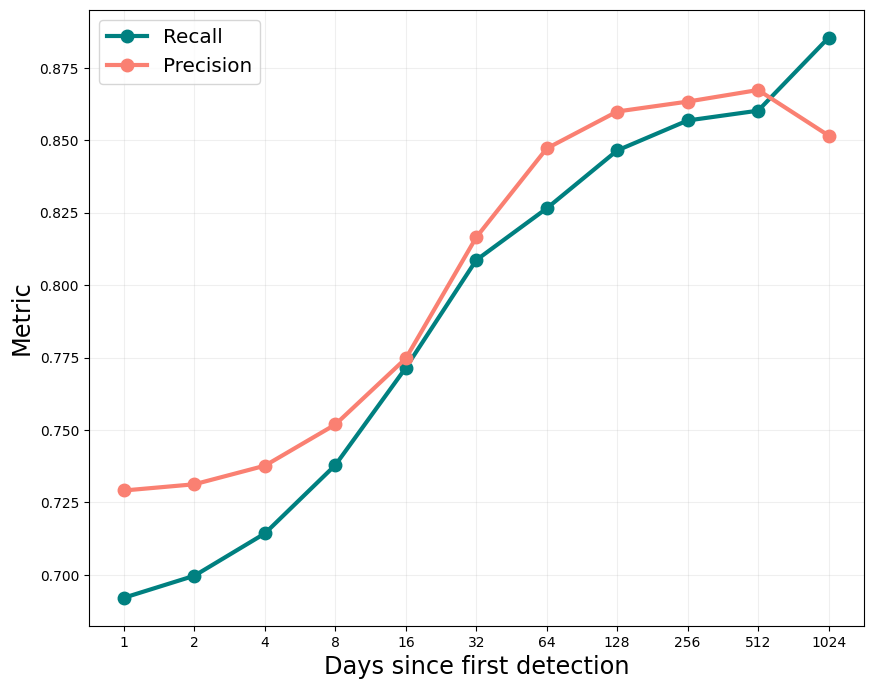

In [49]:
plt.style.use(['default'])
fig, ax = plt.subplots(figsize=(10, 8))

ax.plot(days_for_eval, recall_over_phase, c='teal',  marker='o', markersize=9, label='Recall', linewidth=3)
ax.plot(days_for_eval, precision_over_phase, c='salmon',  marker='o', markersize=9, label='Precision',  linewidth=3)

ax.set_xscale('log')

ax.tick_params(axis="x", which="minor", bottom=False, top=False)
ax.set_xticks(days_for_eval)
ax.set_xticklabels(days_for_eval)


# ax.set_xticklabels(days)

ax.set_ylabel('Metric', fontsize='xx-large')
ax.set_xlabel('Days since first detection', fontsize='xx-large')

plt.legend(fontsize='x-large')
plt.grid(alpha=0.2)

plt.savefig('SLSNe_over_phase.png', dpi=400)


In [50]:
all_classification

SNID,true_g,true,pred,SIM_REDSHIFT_CMB,ELASTICC_class
i64,str,str,str,f64,str
24059994,"""CART""","""Not high-z SLSN-I""","""Not high-z SLSN-I""",0.227604,"""CART"""
69354757,"""CART""","""Not high-z SLSN-I""","""Not high-z SLSN-I""",0.069587,"""CART"""
46671463,"""CART""","""Not high-z SLSN-I""","""Not high-z SLSN-I""",0.132733,"""CART"""
27578480,"""CART""","""Not high-z SLSN-I""","""Not high-z SLSN-I""",0.176058,"""CART"""
35116181,"""CART""","""Not high-z SLSN-I""","""Not high-z SLSN-I""",0.161746,"""CART"""
…,…,…,…,…,…
62009810,"""uLens""","""Not high-z SLSN-I""","""Not high-z SLSN-I""",0.0,"""uLens-Single_PyLIMA"""
13635624,"""uLens""","""Not high-z SLSN-I""","""Not high-z SLSN-I""",0.0,"""uLens-Single_PyLIMA"""
60536405,"""uLens""","""Not high-z SLSN-I""","""Not high-z SLSN-I""",0.0,"""uLens-Single_PyLIMA"""


/Users/vedshah/anaconda3/envs/VT/lib/python3.11/site-packages/numpy/lib/_histograms_impl.py:901: RuntimeWarning: invalid value encountered in divide
  return n/db/n.sum(), bin_edges


Text(0, 0.5, 'Density')

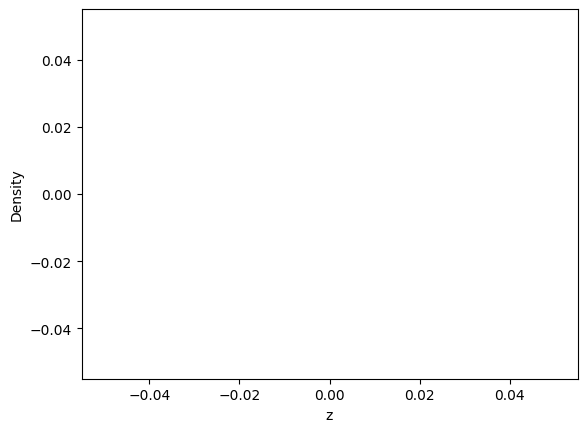

In [51]:
plt.hist(all_classification.filter((all_classification['pred']=='high-z-SLSN'))['SIM_REDSHIFT_CMB'], density=True, bins=20)
plt.xlabel('z')
plt.ylabel('Density')

In [52]:
len(all_classification.filter((all_classification['pred']=='high-z SLSN-I') & (all_classification['SIM_REDSHIFT_CMB']>=1))) /len(all_classification.filter((all_classification['pred']=='high-z SLSN-I')))

0.9269003304922595

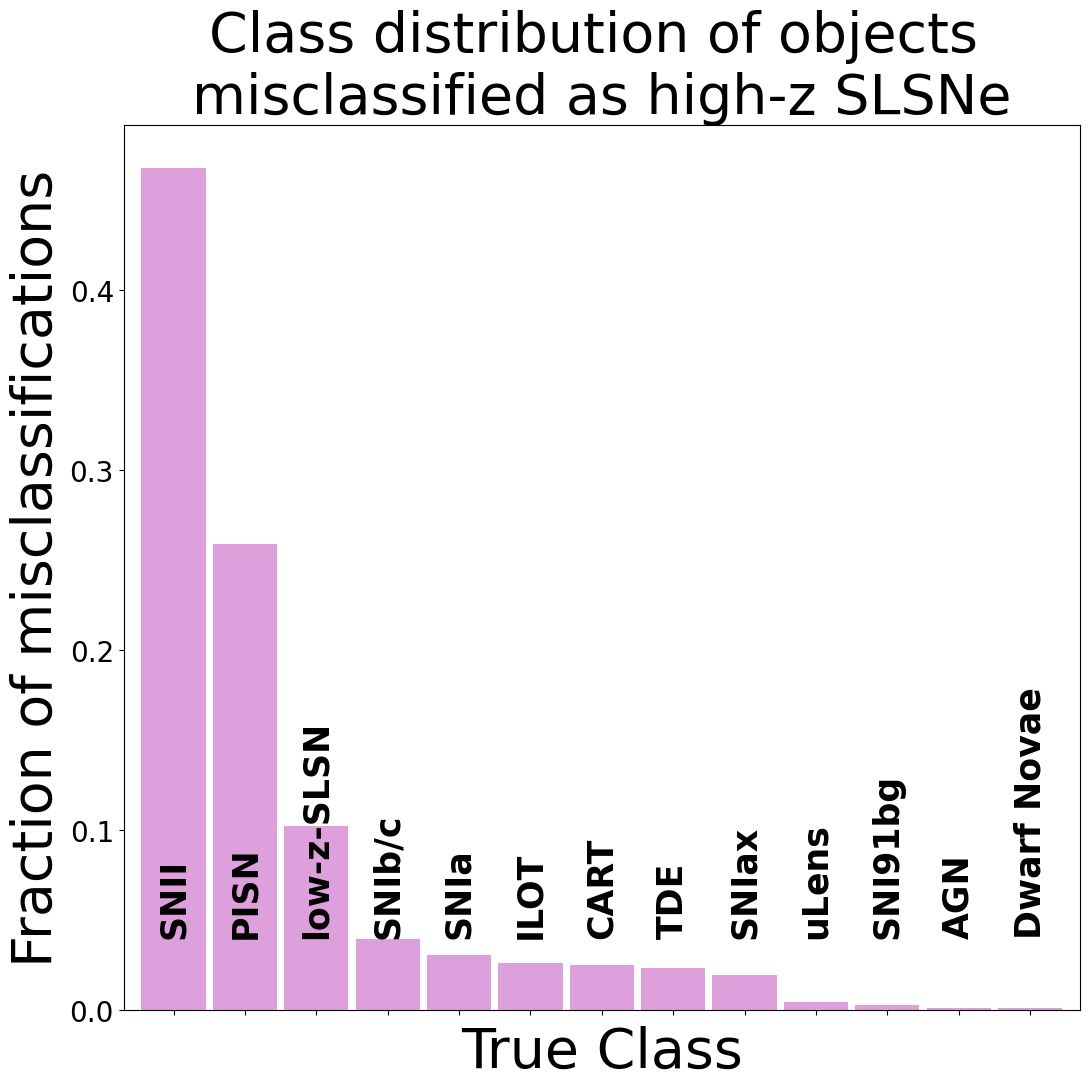

In [53]:
ax = (
    all_classification
    .filter((all_classification['pred'] == 'high-z SLSN-I') & 
            (all_classification['true'] != 'high-z SLSN-I'))
    .to_pandas()['true_g']
    .value_counts(normalize=True)
    .plot(
        kind='bar',
        figsize=(11, 11),
        rot=75,
        width=0.9,
        color='plum',
    )
)

# Move x labels inside the bars
for i, (label, p) in enumerate(zip(ax.get_xticklabels(), ax.patches)):
    

    ax.text(
        p.get_x() + p.get_width() / 2,  # horizontal center of bar
        0.04,             # vertical middle of bar
        label.get_text(),               # the actual label
        ha='center',
        va='bottom',
        rotation=90,                    # vertical for readability
        color='black',
        fontsize=25,
        fontweight='bold'
    )

# Hide default x-axis tick labels
ax.set_xticklabels([])
ax.tick_params(axis='y', labelsize=20)

ax.set_xlabel('True Class', fontsize=40)
ax.set_ylabel('Fraction of misclassifications', fontsize=40)
plt.title("Class distribution of objects \nmisclassified as high-z SLSNe", fontsize=40)


plt.tight_layout()

plt.savefig('class_makeup.pdf', bbox_inches='tight')


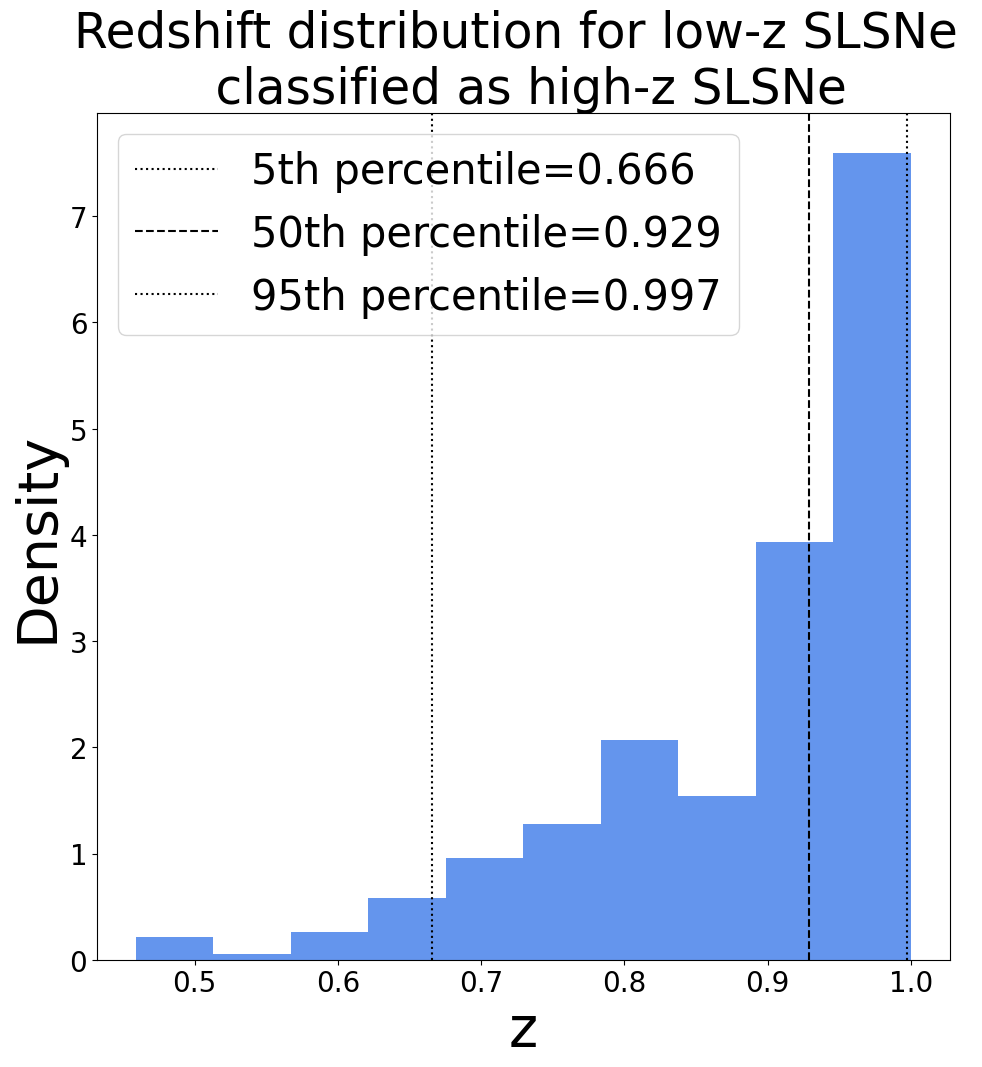

In [54]:
plt.style.use(['default'])
fp_lowzslsne_redshift = all_classification.filter((all_classification['pred']=='high-z SLSN-I') & (all_classification['true_g']=='low-z-SLSN'))['SIM_REDSHIFT_CMB']

fig, ax = plt.subplots(figsize=(11, 11))

plt.hist(fp_lowzslsne_redshift, density=True, color='cornflowerblue')
plt.axvline(np.percentile(fp_lowzslsne_redshift, 5), 0, 5, color='black', linestyle='dotted', label=f"5th percentile={np.percentile(fp_lowzslsne_redshift, 5):.3f}")
plt.axvline(np.percentile(fp_lowzslsne_redshift, 50), 0, 5, color='black', linestyle='dashed', label=f"50th percentile={np.percentile(fp_lowzslsne_redshift, 50):.3f}")
plt.axvline(np.percentile(fp_lowzslsne_redshift, 95), 0, 5, color='black', linestyle='dotted', label=f"95th percentile={np.percentile(fp_lowzslsne_redshift, 95):.3f}")

plt.xlabel('z', fontsize=40)
plt.ylabel('Density', fontsize=40)

plt.title('Redshift distribution for low-z SLSNe \n classified as high-z SLSNe', fontsize=35)

ax.tick_params(axis='x', labelsize=20)
ax.tick_params(axis='y', labelsize=20)

plt.legend(loc='upper left', fontsize=30)
plt.savefig('fp_SLSNe_z_dist.pdf')

In [55]:
all_classification

SNID,true_g,true,pred,SIM_REDSHIFT_CMB,ELASTICC_class
i64,str,str,str,f64,str
24059994,"""CART""","""Not high-z SLSN-I""","""Not high-z SLSN-I""",0.227604,"""CART"""
69354757,"""CART""","""Not high-z SLSN-I""","""Not high-z SLSN-I""",0.069587,"""CART"""
46671463,"""CART""","""Not high-z SLSN-I""","""Not high-z SLSN-I""",0.132733,"""CART"""
27578480,"""CART""","""Not high-z SLSN-I""","""Not high-z SLSN-I""",0.176058,"""CART"""
35116181,"""CART""","""Not high-z SLSN-I""","""Not high-z SLSN-I""",0.161746,"""CART"""
…,…,…,…,…,…
62009810,"""uLens""","""Not high-z SLSN-I""","""Not high-z SLSN-I""",0.0,"""uLens-Single_PyLIMA"""
13635624,"""uLens""","""Not high-z SLSN-I""","""Not high-z SLSN-I""",0.0,"""uLens-Single_PyLIMA"""
60536405,"""uLens""","""Not high-z SLSN-I""","""Not high-z SLSN-I""",0.0,"""uLens-Single_PyLIMA"""


In [56]:
print(all_classification['true_g'].unique().to_list())

['Cepheid', 'Delta Scuti', 'PISN', 'ILOT', 'Dwarf Novae', 'SNII', 'low-z-SLSN', 'SNIb/c', 'KN', 'RR Lyrae', 'SNIa', 'EB', 'SNI91bg', 'M-dwarf Flare', 'high-z-SLSN', 'CART', 'uLens', 'TDE', 'SNIax', 'AGN']


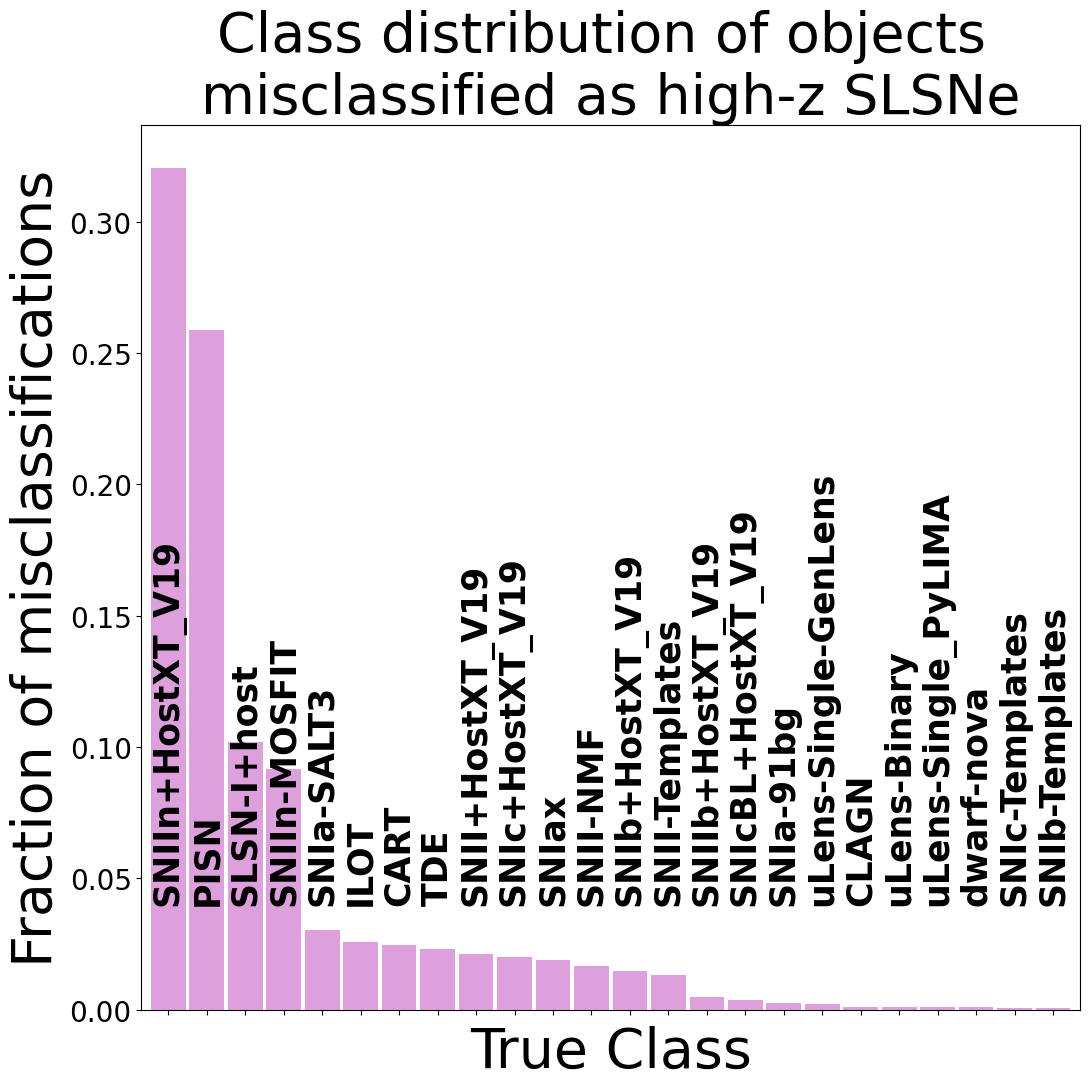

In [61]:
ax = (
    all_classification
    .filter((all_classification['pred'] == 'high-z SLSN-I') & 
            (all_classification['true'] != 'high-z SLSN-I'))
    .to_pandas()['ELASTICC_class']
    .value_counts(normalize=True)
    .plot(
        kind='bar',
        figsize=(11, 11),
        rot=75,
        width=0.9,
        color='plum',
    )
)

# Move x labels inside the bars
for i, (label, p) in enumerate(zip(ax.get_xticklabels(), ax.patches)):
    

    ax.text(
        p.get_x() + p.get_width() / 2,  # horizontal center of bar
        0.04,             # vertical middle of bar
        label.get_text(),               # the actual label
        ha='center',
        va='bottom',
        rotation=90,                    # vertical for readability
        color='black',
        fontsize=25,
        fontweight='bold'
    )

# Hide default x-axis tick labels
ax.set_xticklabels([])
ax.tick_params(axis='y', labelsize=20)

ax.set_xlabel('True Class', fontsize=40)
ax.set_ylabel('Fraction of misclassifications', fontsize=40)
plt.title("Class distribution of objects \nmisclassified as high-z SLSNe", fontsize=40)


plt.tight_layout()

In [63]:
all_classification.filter((all_classification['pred'] == 'high-z SLSN-I') & 
        (all_classification['true'] != 'high-z SLSN-I')).to_pandas()['ELASTICC_class'].value_counts()

ELASTICC_class
SNIIn+HostXT_V19        1094
PISN                     883
SLSN-I+host              348
SNIIn-MOSFIT             313
SNIa-SALT3               103
ILOT                      88
CART                      84
TDE                       79
SNII+HostXT_V19           72
SNIc+HostXT_V19           68
SNIax                     65
SNII-NMF                  57
SNIb+HostXT_V19           50
SNII-Templates            45
SNIIb+HostXT_V19          16
SNIcBL+HostXT_V19         13
SNIa-91bg                  9
uLens-Single-GenLens       8
CLAGN                      4
uLens-Binary               3
uLens-Single_PyLIMA        3
dwarf-nova                 3
SNIc-Templates             2
SNIb-Templates             2
Name: count, dtype: int64

In [64]:
all_classification

SNID,true_g,true,pred,SIM_REDSHIFT_CMB,ELASTICC_class
i64,str,str,str,f64,str
24059994,"""CART""","""Not high-z SLSN-I""","""Not high-z SLSN-I""",0.227604,"""CART"""
69354757,"""CART""","""Not high-z SLSN-I""","""Not high-z SLSN-I""",0.069587,"""CART"""
46671463,"""CART""","""Not high-z SLSN-I""","""Not high-z SLSN-I""",0.132733,"""CART"""
27578480,"""CART""","""Not high-z SLSN-I""","""Not high-z SLSN-I""",0.176058,"""CART"""
35116181,"""CART""","""Not high-z SLSN-I""","""Not high-z SLSN-I""",0.161746,"""CART"""
…,…,…,…,…,…
62009810,"""uLens""","""Not high-z SLSN-I""","""Not high-z SLSN-I""",0.0,"""uLens-Single_PyLIMA"""
13635624,"""uLens""","""Not high-z SLSN-I""","""Not high-z SLSN-I""",0.0,"""uLens-Single_PyLIMA"""
60536405,"""uLens""","""Not high-z SLSN-I""","""Not high-z SLSN-I""",0.0,"""uLens-Single_PyLIMA"""
